**SIOC 251: Homework 1**

Monte Carlo Model of Solar Radiation in an Absorbing Atmosphere


**Author:** Myles Jacobs

**Date:** April 22nd 2026

**Part I: Building the Monte Carlo Model**

Here we simulate the downward movement of photons, relative to the solar zenith angle $\theta$ in an uniform atmosphere of height **$Z_{atm}$**. A given photon either travels completely through, reaching the surface, or it experiences extinction. 

In [19]:
import numpy as np

def run_monte_carlo_atmosphere(num_photons, tau_star, theta_deg, z_atm=1.0):
    """
    Simulates photon extinction in a homogeneous, purely absorbing atmosphere.
    
    Parameters:
    - num_photons: Number of photons entering the atmosphere.
    - tau_star: Total optical depth of the atmosphere.
    - theta_deg: Solar zenith angle in degrees.
    - z_atm: Geometric thickness of the atmosphere (default is 1 scale height).
    
    Returns:
    - transmittance: The fraction of photons that reach the surface.
    """
    # If the sun is at or below the horizon, no photons reach the surface directly
    if theta_deg >= 90.0:
        return 0.0

    # Calculate mu, the cosine of the solar zenith angle
    theta_rad = np.radians(theta_deg)
    mu = np.cos(theta_rad)

    # Step 1: Generate uniformly distributed random numbers between 0 and 1
    zeta = np.random.uniform(0, 1, num_photons)

    # Step 2: Calculate the sampled optical depth traveled by each photon
    tau = -np.log(1 - zeta)
    
    # 3. FIX: Calculate the corresponding geometric pathlength such that mu does not cancel out in the inequality in step 4
    # The physical pathlength L for a generated optical depth tau is:
    L = z_atm * (tau / tau_star)
    
    # Step 4: Determine if each photon reaches the surface or undergoes extinction
    # A photon reaches the surface if its travel distance (L) is greater than or 
    # equal to the total slant path through the atmosphere (Z_atm / mu).
    total_slant_path = z_atm / mu
    
    # Check survival
    photons_reaching_surface = np.sum(L >= total_slant_path)
    transmittance = photons_reaching_surface / num_photons
    
    return transmittance

# --- Execution ---
transmittance_overhead = run_monte_carlo_atmosphere(100000, 1.0, 0.0)
transmittance_angled = run_monte_carlo_atmosphere(100000, 1.0, 60.0)

print(f"Overhead (0 deg): {transmittance_overhead:.5f}")
print(f"Angled (60 deg): {transmittance_angled:.5f}")

Overhead (0 deg): 0.36949
Angled (60 deg): 0.13485


**Part II: Model Verification**

Verification tests: limiting cases. 

Case 1; sun at the horizon, $\theta = 90^\circ$. We should then expect transmittance $T = 0$

Case 2; no atmosphere, $\tau^* \to 0$. We should then expect transmittance $T = 1$

In [20]:
#Case 1:
transmittance_horizon = run_monte_carlo_atmosphere(100000, 1.0, 90.0)
print(f"Horizon (90 deg): {transmittance_horizon:.5f}")

Horizon (90 deg): 0.00000


In [23]:
#Case 2:
#A divide by zero error occurs when tau_star is set to zero, lets set it to an extremely low value instead
transmittance_noatm = run_monte_carlo_atmosphere(100000, 0.0000000001, 0.0)
print(f"No atmosphere: {transmittance_noatm:.5f}")

No atmosphere: 1.00000


**Part III: Radiative Transfer Experiments**
1. Coincidentally, we already verified that for $\theta = 0$, and $\tau = 1$, we see a reduction in the intensity by a factor of exactly euler's number, i.e.: transmittance is equal to $e^{-1}$, or approximately $0.378$
2. For $\tau = 1$, we also already checked the case that $\theta = 60^\circ$, which produced a transmittance $T = 0.13485$
3. In a purely absorbing atmosphere, assuming the sun is a point source, we've neglected all the real life effects of scattering, or the circumsolar region, which make sunsets so beautiful, with all the reds and oranges (or other colors as well, if you're in a particularly polluted area such as LA,) completely invisible. Thus, at the point source at exactly 90 degrees (or greater) from the zenith angle, a straight beam of light would be travelling completely parallel to the surface, never interacting, and therefore always eventually becoming completely absorbed by the atmosphere.
4. Here's some more code below to try out other values of $\tau$ (1, 3, 10) in relation to height:

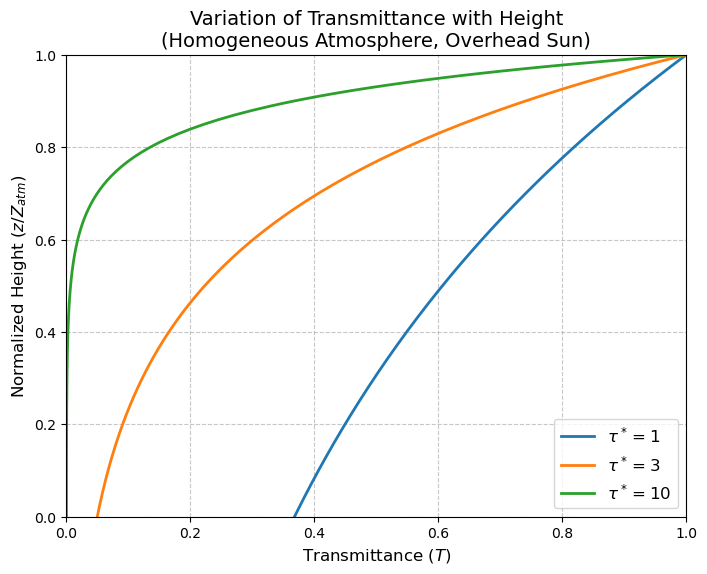

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Values provided in the assignment
tau_values = [1, 3, 10]
z_atm = 1.0  # Normalized to 1 scale height

# Create an array of heights from the top of the atmosphere (1.0) down to the surface (0.0)
heights = np.linspace(1.0, 0.0, 200)

# We will assume the sun is directly overhead (mu = 1) for the baseline visualization
mu = 1.0

plt.figure(figsize=(8, 6))

for tau_star in tau_values:
    # In a homogeneous atmosphere, optical depth increases linearly from the top down.
    # tau_z represents the optical depth from the top down to the current height 'z'.
    tau_z = tau_star * (1 - heights / z_atm)
    
    # Calculate analytical transmittance at each height
    transmittance = np.exp(-tau_z / mu)
    
    # Plotting height on the y-axis and transmittance on the x-axis
    plt.plot(transmittance, heights, label=rf'$\tau^* = {tau_star}$', linewidth=2)

# Formatting the plot
plt.title('Variation of Transmittance with Height\n(Homogeneous Atmosphere, Overhead Sun)', fontsize=14)
plt.xlabel('Transmittance ($T$)', fontsize=12)
plt.ylabel('Normalized Height ($z / Z_{atm}$)', fontsize=12)

# Set axes limits to match physical boundaries
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the figure to the 'figures' directory as requested in the assignment structure
import os
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/transmittance_vs_height.png', dpi=300, bbox_inches='tight')

plt.show()

**Part IV: AERONET Observations**

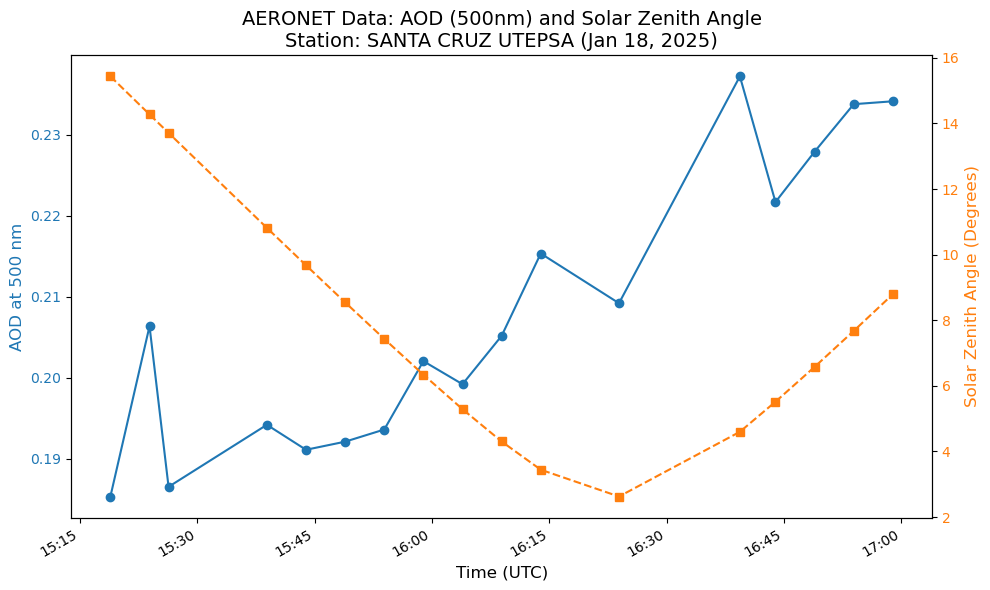

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 1. Load the data
file_name = "20250118_20250118_SANTA_CRUZ_UTEPSA.lev20"

# AERONET files have 6 lines of metadata before the actual column headers
df = pd.read_csv(file_name, skiprows=6)

# De-fragment the dataframe to prevent the PerformanceWarning
df = df.copy()

# 2. Data Cleaning & Preparation
# Combine the Date and Time columns into a single datetime object for the x-axis
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')

# AERONET uses -999.0 to indicate missing or invalid data. We must filter these out.
df = df[df['AOD_500nm'] >= 0]

# 3. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AOD on the left y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Time (UTC)', fontsize=12)
ax1.set_ylabel('AOD at 500 nm', color=color1, fontsize=12)
ax1.plot(df['Datetime'], df['AOD_500nm'], marker='o', linestyle='-', color=color1, label='AOD 500nm')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis for the Solar Zenith Angle on the right
ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Solar Zenith Angle (Degrees)', color=color2, fontsize=12)  
ax2.plot(df['Datetime'], df['Solar_Zenith_Angle(Degrees)'], marker='s', linestyle='--', color=color2, label='Solar Zenith Angle')
ax2.tick_params(axis='y', labelcolor=color2)

# Format the x-axis to show hours clearly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

plt.title('AERONET Data: AOD (500nm) and Solar Zenith Angle\nStation: SANTA CRUZ UTEPSA (Jan 18, 2025)', fontsize=14)
fig.tight_layout()  

# 4. Save the figure to your homework directory
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/aeronet_aod_sza.png', dpi=300, bbox_inches='tight')

plt.show()

**Question 5**
1. The primary source of aerosols at this station on this day is smoke from wildfires in brasil.
2. The direct transmittance at the surface decreases somewhat steadily throughtout the day.
3. For a constant $\tau$, which assumes that we're keeping the amount of aersols in the atmosphere constant, the only thing variable would be the path length of light from about $15^\circ$, to $2.6^\circ$ at solar noon, then going back up. As a result, transmittance *should* peak at noon. However, our graph shows something very different, leading me to believe that $\tau$, and therefore the concentration of aerosols in the air, should be steadily increasing.
4. For a constant $\theta$, the peak would correspond with whenever the highest amount of aerosols were concentrated in the atmosphere, i.e.: at a maximum optical depth $\tau$.
5. Clearly, $\tau$ is the factor most responsible for changes in transmittance over the course of January 18th in Bolivia. The solar zenith angle only varies from $15^\circ$ to $2^\circ$, with respective cosines equal to 0.96 and ~1.0. Meanwhile, our AOD as a function of $\tau$ increases from 0.18 to 0.23 throughout the day, which is nearly a 30% increase that can, mathematically, only be accounted for by a steady increase of the optical depth throughout the day.

**Part V: Student Investigation**

Question: How does Aerosol Optical Depth vary in the infrared spectrum (for this we will use 870nm)?
Hypothesis: IR optical depth can often make clouds appear as black bodies, so I predict that the optical depth for the smoke plumes in Bolivia should be higher, and less varying than in the visible spectrum.
Experiment: Generate a new figure for the same AOD data at a new wavelength and compare figures.

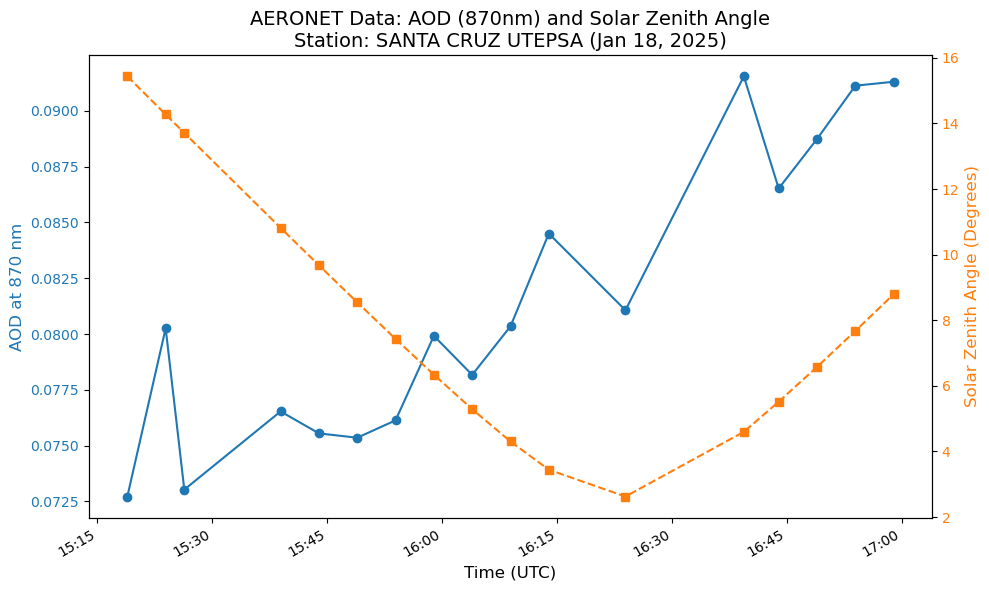

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# 1. Load the data
file_name = "20250118_20250118_SANTA_CRUZ_UTEPSA.lev20"

# AERONET files have 6 lines of metadata before the actual column headers
df = pd.read_csv(file_name, skiprows=6)

# De-fragment the dataframe to prevent the PerformanceWarning
df = df.copy()

# 2. Data Cleaning & Preparation
# Combine the Date and Time columns into a single datetime object for the x-axis
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')

# AERONET uses -999.0 to indicate missing or invalid data. We must filter these out.
df = df[df['AOD_870nm'] >= 0]

# 3. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot AOD on the left y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Time (UTC)', fontsize=12)
ax1.set_ylabel('AOD at 870 nm', color=color1, fontsize=12)
ax1.plot(df['Datetime'], df['AOD_870nm'], marker='o', linestyle='-', color=color1, label='AOD 870nm')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis for the Solar Zenith Angle on the right
ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Solar Zenith Angle (Degrees)', color=color2, fontsize=12)  
ax2.plot(df['Datetime'], df['Solar_Zenith_Angle(Degrees)'], marker='s', linestyle='--', color=color2, label='Solar Zenith Angle')
ax2.tick_params(axis='y', labelcolor=color2)

# Format the x-axis to show hours clearly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()

plt.title('AERONET Data: AOD (870nm) and Solar Zenith Angle\nStation: SANTA CRUZ UTEPSA (Jan 18, 2025)', fontsize=14)
fig.tight_layout()  

# 4. Save the figure to your homework directory
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/aeronet_aod_sza.png', dpi=300, bbox_inches='tight')

plt.show()

**Part V; Conclusions**

It appears my hypothesis was incorrect! The graph appears to behave almost the exact same, except that the optical depth is *tiny* in comparison to the visible spectrum. I was incorrect to believe that smoke plumes and clouds would behave similarly. Of course, clouds appear as blackbodies in the IR spectrum, while smoke is *nearly invisible* because water molecules forming as ice or liquid droplets are much larger than sulfates or soot particles in smoke!

**AI USAGE**

*Tool:* Gemini pro for students

*Usage:*
+ Generated code for original Monte Carlo Model
+ Created and saved plots to directory from code environment
+ Generated code to read and plot AERONET data
+ Assisted with errors in reading AERONET file and fixing the monte carlo model inequality (denoted in a comment)